In [1]:
import os
os.chdir("../")

In [2]:
import torch
from src.constants import DEVICE
from src.models import ModelManager
from src.config.manager import ConfigurationManager
import chess
import chess.svg
from IPython.display import display, clear_output
import numpy as np
from src.utils import fen_to_tensor, tensor_to_fen, plot_planes

In [3]:
config = ConfigurationManager()

In [4]:
model = ModelManager(config=config).load_model()

In [5]:
def predict(input_tensor: torch.Tensor, model: torch.nn.Module=model) -> torch.Tensor:
    model.eval()

    with torch.no_grad():
        output = model(input_tensor)
    
    return output

In [6]:
trial_fen = "2kr4/p1p3pp/4p3/Rq6/8/5QPP/8/6K1 w - - 0 1"

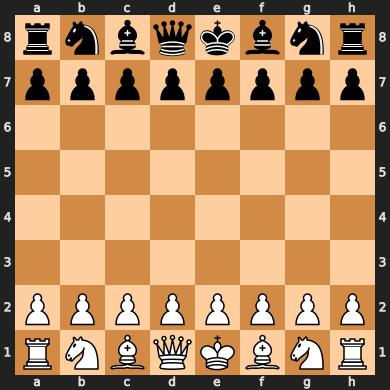

In [7]:
board = chess.Board()
board

In [8]:
inputt = fen_to_tensor(trial_fen)
inputt

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 1, 1],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

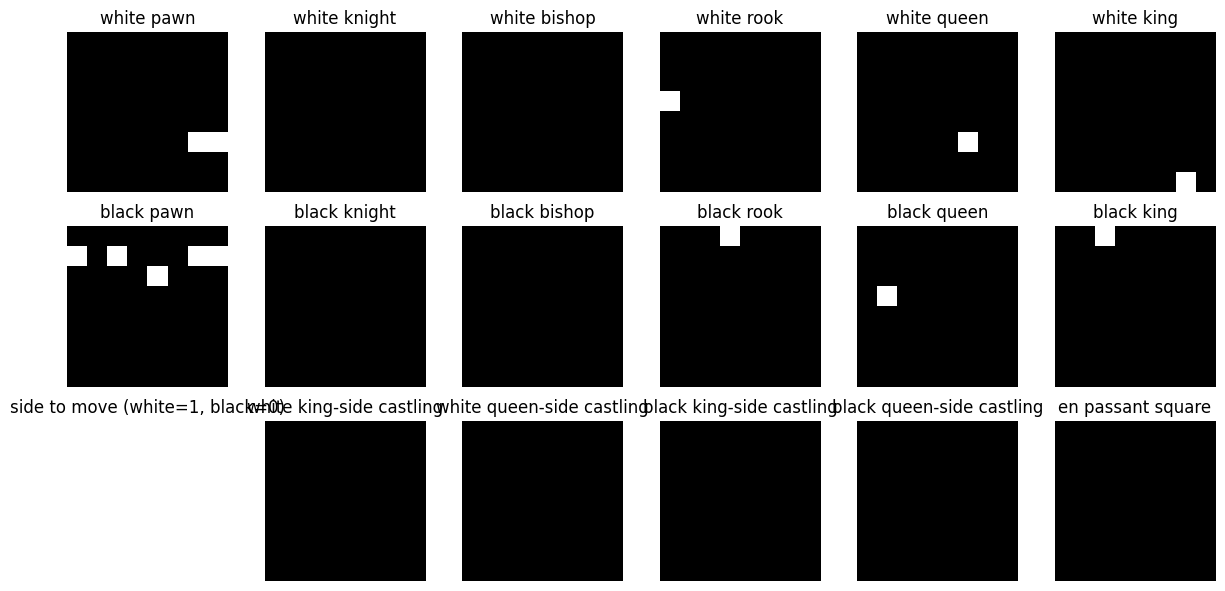

In [9]:
plot_planes(inputt)

In [10]:
predict(torch.from_numpy(inputt).unsqueeze(0).float())

tensor([[0.7198]])

In [11]:
legal_moves = []

In [12]:
for move in board.generate_legal_moves():
    board.push(move)
    # display(chess.svg.board(board, size=350))
    legal_moves.append(board.fen())
    board.pop()

In [13]:
legal_moves

['rnbqkbnr/pppppppp/8/8/8/7N/PPPPPPPP/RNBQKB1R b KQkq - 1 1',
 'rnbqkbnr/pppppppp/8/8/8/5N2/PPPPPPPP/RNBQKB1R b KQkq - 1 1',
 'rnbqkbnr/pppppppp/8/8/8/2N5/PPPPPPPP/R1BQKBNR b KQkq - 1 1',
 'rnbqkbnr/pppppppp/8/8/8/N7/PPPPPPPP/R1BQKBNR b KQkq - 1 1',
 'rnbqkbnr/pppppppp/8/8/8/7P/PPPPPPP1/RNBQKBNR b KQkq - 0 1',
 'rnbqkbnr/pppppppp/8/8/8/6P1/PPPPPP1P/RNBQKBNR b KQkq - 0 1',
 'rnbqkbnr/pppppppp/8/8/8/5P2/PPPPP1PP/RNBQKBNR b KQkq - 0 1',
 'rnbqkbnr/pppppppp/8/8/8/4P3/PPPP1PPP/RNBQKBNR b KQkq - 0 1',
 'rnbqkbnr/pppppppp/8/8/8/3P4/PPP1PPPP/RNBQKBNR b KQkq - 0 1',
 'rnbqkbnr/pppppppp/8/8/8/2P5/PP1PPPPP/RNBQKBNR b KQkq - 0 1',
 'rnbqkbnr/pppppppp/8/8/8/1P6/P1PPPPPP/RNBQKBNR b KQkq - 0 1',
 'rnbqkbnr/pppppppp/8/8/8/P7/1PPPPPPP/RNBQKBNR b KQkq - 0 1',
 'rnbqkbnr/pppppppp/8/8/7P/8/PPPPPPP1/RNBQKBNR b KQkq - 0 1',
 'rnbqkbnr/pppppppp/8/8/6P1/8/PPPPPP1P/RNBQKBNR b KQkq - 0 1',
 'rnbqkbnr/pppppppp/8/8/5P2/8/PPPPP1PP/RNBQKBNR b KQkq - 0 1',
 'rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1

In [14]:
legal_moves_np = np.array([fen_to_tensor(move) for move in legal_moves])

In [15]:
legal_moves_np

array([[[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [1, 1, 1, ..., 1, 1, 1],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 1],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 1, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 1, ..., 1, 0, 0]],

        ...,

        [[1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
         ...,
         [1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1]],

        [[1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
         [1, 1, 1, ..., 1, 1, 1],
    

In [16]:
results = predict(torch.from_numpy(legal_moves_np).float())

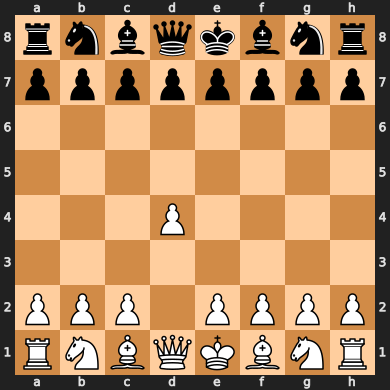

In [17]:
chess.Board(legal_moves[results.argmax().item()])